# 01-EDA

In [1]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve().parent   # assumes notebook is in /notebooks
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

SUPPLY_PATH = PROCESSED_DIR / "supply_chain_risk_clean.csv"
COMMODITY_PATH = PROCESSED_DIR / "commodity_prices_clean.csv"
OVERLAP_PATH = PROCESSED_DIR / "supply_chain_enriched_overlap.csv"

df_supply = pd.read_csv(SUPPLY_PATH, parse_dates=["date"])
df_com_price = pd.read_csv(COMMODITY_PATH)
df_overlap = pd.read_csv(OVERLAP_PATH, parse_dates=["date", "month"])

df_com_price["month"] = pd.to_datetime(
    df_com_price["period_code"].str.replace("M", "-", regex=False),
    format="%Y-%m"
)


In [2]:
df_supply.head()

,shipment_id,date,origin_port,destination_port,transport_mode,product_category,distance_km,weight_mt,fuel_price_index,geopolitical_risk_score,weather_condition,carrier_reliability_score,lead_time_days,disruption_occurred
0,SC-10000,2025-10-16,Singapore,Los Angeles,Rail,Textiles,5930.83,197.42,2.43,5.0,Hurricane,0.865,41.39,1
1,SC-10001,2024-04-24,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1
2,SC-10002,2024-01-26,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0
3,SC-10003,2024-10-08,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1
4,SC-10004,2024-09-07,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1


In [3]:
df_com_price.head()

,period_code,crude_oil_average__usd_per_bbl,crude_oil_brent__usd_per_bbl,crude_oil_dubai__usd_per_bbl,crude_oil_wti__usd_per_bbl,coal_australian__usd_per_mt,coal_south_african__usd_per_mt,natural_gas_us__usd_per_mmbtu,natural_gas_europe__usd_per_mmbtu,liquefied_natural_gas_japan__usd_per_mmbtu,...,iron_ore_cfr_spot__usd_per_dmtu,copper__usd_per_mt,lead__usd_per_mt,tin__usd_per_mt,nickel__usd_per_mt,zinc__usd_per_mt,gold__usd_per_troy_oz,platinum__usd_per_troy_oz,silver__usd_per_troy_oz,month
0,1960M01,1.63,1.63,1.63,NaN,NaN,NaN,0.14,0.404774,NaN,...,11.42,715.40,206.1,2180.4,1631.0,260.8,35.27,83.5,0.9137,1960-01-01
1,1960M02,1.63,1.63,1.63,NaN,NaN,NaN,0.14,0.404774,NaN,...,11.42,728.19,203.7,2180.4,1631.0,244.9,35.27,83.5,0.9137,1960-02-01
2,1960M03,1.63,1.63,1.63,NaN,NaN,NaN,0.14,0.404774,NaN,...,11.42,684.94,210.3,2173.8,1631.0,248.7,35.27,83.5,0.9137,1960-03-01
3,1960M04,1.63,1.63,1.63,NaN,NaN,NaN,0.14,0.404774,NaN,...,11.42,723.11,213.6,2178.2,1631.0,254.6,35.27,83.5,0.9137,1960-04-01
4,1960M05,1.63,1.63,1.63,NaN,NaN,NaN,0.14,0.404774,NaN,...,11.42,684.75,213.4,2162.7,1631.0,253.8,35.27,83.5,0.9137,1960-05-01


In [4]:
df_overlap.head()

,shipment_id,date,month,origin_port,destination_port,transport_mode,product_category,distance_km,weight_mt,fuel_price_index,geopolitical_risk_score,weather_condition,carrier_reliability_score,lead_time_days,disruption_occurred,copper__usd_per_mt
0,SC-10001,2024-04-24,2024-04-01,Singapore,Shanghai,Rail,Automotive,14285.36,237.24,2.30,7.5,Storm,0.592,40.92,1,9464.43
1,SC-10002,2024-01-26,2024-01-01,Rotterdam,Los Angeles,Rail,Perishables,11113.91,427.42,1.78,5.6,Rain,0.673,11.54,0,8338.88
2,SC-10003,2024-10-08,2024-10-01,Busan,Hamburg,Rail,Electronics,9180.55,170.66,3.20,0.8,Hurricane,0.832,53.13,1,9533.99
3,SC-10004,2024-09-07,2024-09-01,Busan,Singapore,Air,Perishables,2762.27,434.96,2.77,1.9,Fog,0.741,0.50,1,9237.48
4,SC-10005,2024-08-16,2024-08-01,Rotterdam,Marseille,Rail,Automotive,2761.92,44.98,4.06,2.2,Rain,0.869,2.16,1,8971.96


## Regression EDA checklist

Goal of this notebook: decide whether `lead_time_days` is a suitable regression target, inspect all available variables, identify missing values and outliers, and define a first leakage-safe feature set for modeling.


In [5]:
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

TARGET_COL = "lead_time_days"

# Columns that should not be used directly as model inputs.
ID_COLS = ["shipment_id"]
DATE_COLS = ["date", "month"]

# This column is likely an outcome/after-the-fact event indicator.
# For a pre-shipment lead-time model, it should be excluded from predictors.
POTENTIAL_LEAKAGE_COLS = ["disruption_occurred"]

EXCLUDE_FROM_FEATURES = ID_COLS + DATE_COLS + [TARGET_COL] + POTENTIAL_LEAKAGE_COLS

candidate_feature_cols = [c for c in df_overlap.columns if c not in EXCLUDE_FROM_FEATURES]

print("Shape df_supply:", df_supply.shape)
print("Shape df_com_price:", df_com_price.shape)
print("Shape df_overlap:", df_overlap.shape)
print("\nCandidate feature columns:")
print(candidate_feature_cols)


Shape df_supply: (5000, 14)
Shape df_com_price: (780, 73)
Shape df_overlap: (2455, 16)

Candidate feature columns:
['origin_port', 'destination_port', 'transport_mode', 'product_category', 'distance_km', 'weight_mt', 'fuel_price_index', 'geopolitical_risk_score', 'weather_condition', 'carrier_reliability_score', 'copper__usd_per_mt']


## 1. Basic structure, data types & nans

This section checks whether the exported SQL dataset has the expected structure and whether columns were imported with sensible data types.


In [6]:
def basic_overview(df: pd.DataFrame, name: str) -> pd.DataFrame:
    overview = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str).values,
        "n_missing": df.isna().sum().values,
        "pct_missing": (df.isna().mean() * 100).round(2).values,
        "n_unique": df.nunique(dropna=True).values,
    })
    print(f"{name}: {df.shape[0]} rows x {df.shape[1]} columns")
    return overview.sort_values(["pct_missing", "n_unique"], ascending=[False, False])

basic_overview(df_overlap, "df_overlap")


df_overlap: 2455 rows x 16 columns


,column,dtype,n_missing,pct_missing,n_unique
0,shipment_id,object,0,0.0,2455
7,distance_km,float64,0,0.0,2454
8,weight_mt,float64,0,0.0,2402
13,lead_time_days,float64,0,0.0,1590
12,carrier_reliability_score,float64,0,0.0,500
1,date,datetime64[ns],0,0.0,366
9,fuel_price_index,float64,0,0.0,331
10,geopolitical_risk_score,float64,0,0.0,101
2,month,datetime64[ns],0,0.0,12
15,copper__usd_per_mt,float64,0,0.0,12


INTERPRETATION: no missing values 

## 2. Target distribution: `lead_time_days`

This section checks whether the target is numeric, non-missing, plausible, and whether extreme values may need special treatment.


In [9]:
target = df_overlap[TARGET_COL]

print("Target dtype:", target.dtype)
print("Missing:", target.isna().sum())
print("Non-positive values:", (target <= 0).sum())

target.describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]).to_frame()


Target dtype: float64
Missing: 0
Non-positive values: 0


,lead_time_days
count,2455.000000
mean,18.976660
std,29.908269
min,0.500000
1%,0.500000
5%,0.500000
10%,0.600000
25%,2.160000
50%,8.170000
75%,21.210000


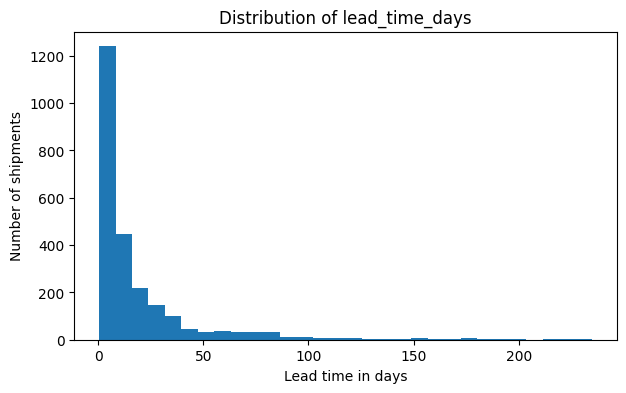

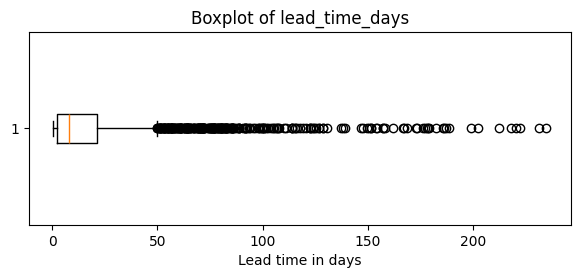

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(target.dropna(), bins=30)
ax.set_xlabel("Lead time in days")
ax.set_ylabel("Number of shipments")
ax.set_title("Distribution of lead_time_days")
plt.show()

fig, ax = plt.subplots(figsize=(7, 2.5))
ax.boxplot(target.dropna(), vert=False)
ax.set_xlabel("Lead time in days")
ax.set_title("Boxplot of lead_time_days")
plt.show()


In [24]:
outlier_flag = df_overlap["lead_time_days"] > 49.79

df_overlap.groupby(outlier_flag)[[
    "distance_km",
    "weight_mt",
    "fuel_price_index",
    "geopolitical_risk_score",
    "carrier_reliability_score",
    "lead_time_days"
]].median()

,distance_km,weight_mt,fuel_price_index,geopolitical_risk_score,carrier_reliability_score,lead_time_days
lead_time_days,,,,,,
False,7090.850,240.840,2.840,5.0,0.753,7.04
True,10828.605,245.145,2.775,5.5,0.756,78.61


In [25]:
pd.crosstab(outlier_flag, df_overlap["transport_mode"], normalize="index")

transport_mode,Air,Rail,Road,Sea
lead_time_days,,,,
False,0.296145,0.239909,0.239456,0.22449
True,0.000000,0.240000,0.224000,0.53600


In [26]:
pd.crosstab(outlier_flag, df_overlap["weather_condition"], normalize="index")

weather_condition,Clear,Fog,Hurricane,Rain,Storm
lead_time_days,,,,,
False,0.217234,0.231293,0.128798,0.22449,0.198186
True,0.000000,0.000000,0.852000,0.00000,0.148000


INTERPRETATION

Target distribution check:
lead_time_days was inspected using summary statistics, histogram, boxplot, and feature comparisons for long-delay cases. The target was strongly right-skewed, but high lead-time values were concentrated in plausible operational conditions, especially longer distances, sea transport, and severe weather. Therefore, all target values were retained.

## 3. Numeric feature checks

This section checks ranges, missingness, and outlier counts for numeric candidate predictors.


In [27]:
df_overlap.columns

Index(['shipment_id', 'date', 'month', 'origin_port', 'destination_port', 'transport_mode', 'product_category', 'distance_km', 'weight_mt', 'fuel_price_index',
       'geopolitical_risk_score', 'weather_condition', 'carrier_reliability_score', 'lead_time_days', 'disruption_occurred', 'copper__usd_per_mt'],
      dtype='object')

In [12]:
numeric_feature_cols = df_overlap[candidate_feature_cols].select_dtypes(include=np.number).columns.tolist()
categorical_feature_cols = [c for c in candidate_feature_cols if c not in numeric_feature_cols]

print("Numeric candidate features:")
print(numeric_feature_cols)

print("\nCategorical candidate features:")
print(categorical_feature_cols)


Numeric candidate features:
['distance_km', 'weight_mt', 'fuel_price_index', 'geopolitical_risk_score', 'carrier_reliability_score', 'copper__usd_per_mt']

Categorical candidate features:
['origin_port', 'destination_port', 'transport_mode', 'product_category', 'weather_condition']


In [28]:
numeric_summary = df_overlap[numeric_feature_cols].describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
).T


numeric_summary


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
distance_km,2455.0,7726.645943,4167.769244,500.45,678.1948,1245.097,4105.565,7695.470,11320.750,14283.498,14875.0592,14995.91
weight_mt,2455.0,244.835055,143.826063,1.03,6.1590,26.485,119.920,241.630,367.370,473.030,493.4300,499.45
fuel_price_index,2455.0,2.853967,0.963598,1.20,1.2300,1.350,2.020,2.830,3.705,4.350,4.4700,4.50
geopolitical_risk_score,2455.0,5.007576,2.864553,0.00,0.1000,0.500,2.500,5.100,7.400,9.500,9.9000,10.00
carrier_reliability_score,2455.0,0.754036,0.144221,0.50,0.5050,0.528,0.627,0.754,0.879,0.979,0.9940,1.00
copper__usd_per_mt,2455.0,9158.621389,511.397995,8304.95,8304.9500,8304.950,8916.320,9237.480,9533.990,10139.330,10139.3300,10139.33


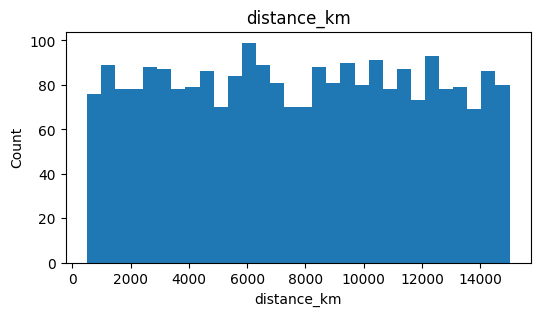

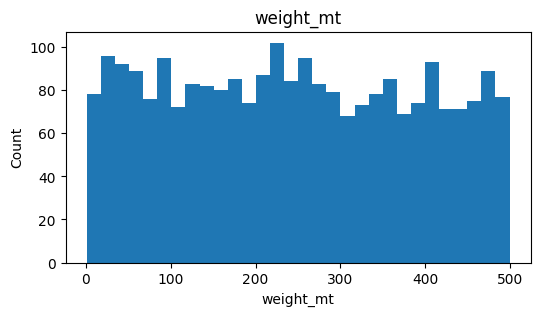

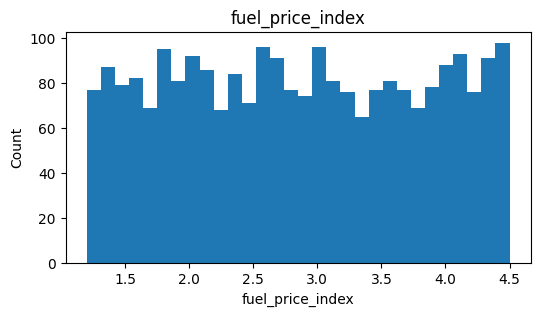

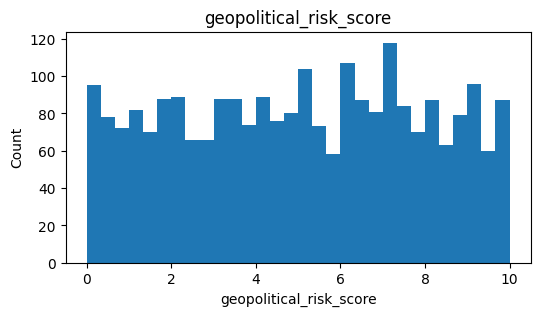

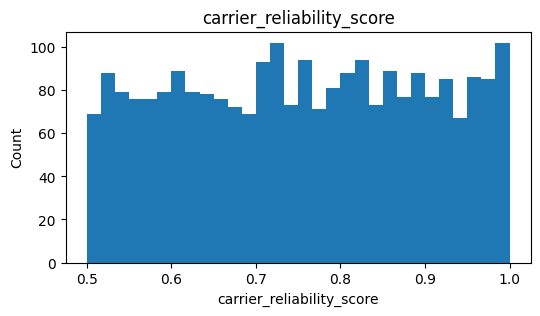

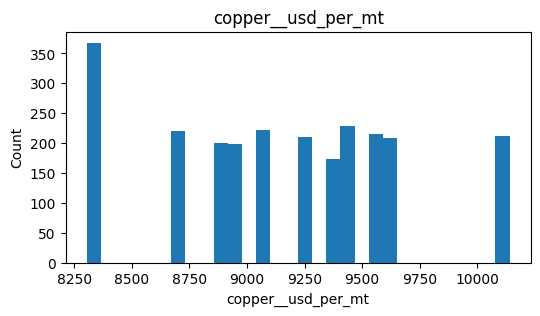

In [ ]:
# Quick histograms for numeric candidate features.

for col in numeric_feature_cols:
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.hist(df_overlap[col].dropna(), bins=30)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    plt.show()


INTERPRETATION  

Numeric feature check:
All candidate numeric features had complete values and plausible ranges.

## 4. Categorical feature checks

This section checks cardinality and rare categories. High-cardinality columns may still be usable, but they need careful encoding.


In [16]:
categorical_summary = []

for col in categorical_feature_cols:
    counts = df_overlap[col].value_counts(dropna=False)
    categorical_summary.append({
        "column": col,
        "n_unique_including_nan": df_overlap[col].nunique(dropna=False),
        "pct_missing": round(df_overlap[col].isna().mean() * 100, 2),
        "most_common": counts.index[0],
        "most_common_count": int(counts.iloc[0]),
        "most_common_pct": round(counts.iloc[0] / len(df_overlap) * 100, 2),
    })

pd.DataFrame(categorical_summary).sort_values("n_unique_including_nan", ascending=False)


,column,n_unique_including_nan,pct_missing,most_common,most_common_count,most_common_pct
1,destination_port,9,0.0,Marseille,288,11.73
0,origin_port,8,0.0,Busan,336,13.69
3,product_category,5,0.0,Textiles,513,20.90
4,weather_condition,5,0.0,Fog,510,20.77
2,transport_mode,4,0.0,Air,653,26.60


In [17]:
for col in categorical_feature_cols:
    print("\n" + "=" * 80)
    print(col)
    display(df_overlap[col].value_counts(dropna=False).head(20).to_frame("count"))



origin_port


,count
origin_port,
Busan,336
Shanghai,330
Rotterdam,314
Los Angeles,314
Dubai,304
Antwerp,290
Hamburg,284
Singapore,283



destination_port


,count
destination_port,
Marseille,288
Dubai,284
Rotterdam,280
Shanghai,276
Los Angeles,273
Antwerp,272
Busan,271
Singapore,264
Hamburg,247



transport_mode


,count
transport_mode,
Air,653
Sea,629
Rail,589
Road,584



product_category


,count
product_category,
Textiles,513
Pharmaceuticals,499
Automotive,483
Electronics,482
Perishables,478



weather_condition


,count
weather_condition,
Fog,510
Hurricane,497
Rain,495
Clear,479
Storm,474


INTERPRETATION

Use text categories in the raw/API input. Encode categorical variables with OneHotEncoder inside the scikit-learn pipeline. No manual numeric coding and no rare-category grouping for version 1.

## 5. Relationship between features and target

This section gives a first rough check of which variables are associated with lead time. This is not final model interpretation.


## a) numeric variables

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

target = "lead_time_days"

numeric_features = [
    "distance_km",
    "weight_mt",
    "fuel_price_index",
    "geopolitical_risk_score",
    "carrier_reliability_score",
    "copper__usd_per_mt",
]

corr_df = df_overlap[numeric_features + [target]].copy()

In [33]:
target_corr = []

for feature in numeric_features:
    tmp = corr_df[[feature, target]].dropna()
    
    target_corr.append({
        "feature": feature,
        "pearson_r": tmp[feature].corr(tmp[target], method="pearson"),
        "spearman_r": tmp[feature].corr(tmp[target], method="spearman"),
        "n": len(tmp)
    })

target_corr = (
    pd.DataFrame(target_corr)
    .assign(abs_spearman=lambda x: x["spearman_r"].abs())
    .sort_values("abs_spearman", ascending=False)
    .drop(columns="abs_spearman")
)

target_corr


,feature,pearson_r,spearman_r,n
0,distance_km,0.324369,0.416998,2455
3,geopolitical_risk_score,0.086013,0.093564,2455
5,copper__usd_per_mt,0.005376,-0.009330,2455
1,weight_mt,0.004689,0.006320,2455
4,carrier_reliability_score,0.008057,0.002882,2455
2,fuel_price_index,-0.000336,-0.001660,2455


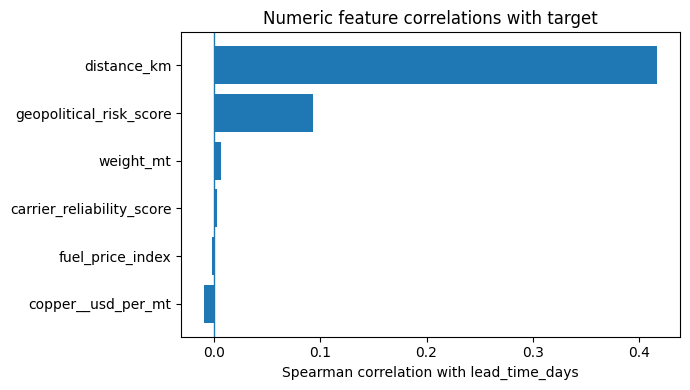

In [34]:
plot_df = target_corr.sort_values("spearman_r")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(plot_df["feature"], plot_df["spearman_r"])
ax.axvline(0, linewidth=1)
ax.set_xlabel("Spearman correlation with lead_time_days")
ax.set_title("Numeric feature correlations with target")
plt.tight_layout()
plt.show()

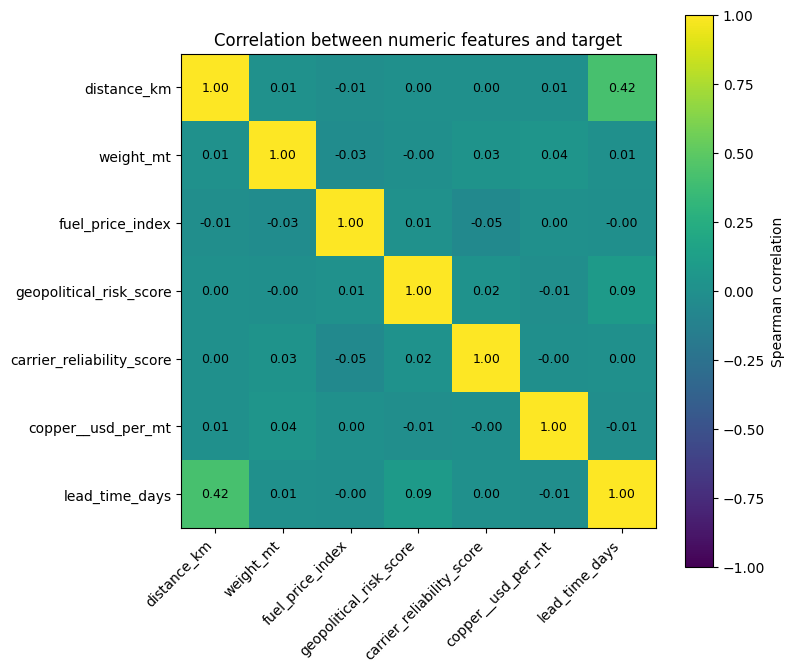

In [36]:
feature_target_corr = df_overlap[numeric_features + [target]].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(feature_target_corr, vmin=-1, vmax=1)

ax.set_xticks(np.arange(len(feature_target_corr.columns)))
ax.set_yticks(np.arange(len(feature_target_corr.index)))
ax.set_xticklabels(feature_target_corr.columns, rotation=45, ha="right")
ax.set_yticklabels(feature_target_corr.index)

for i in range(feature_target_corr.shape[0]):
    for j in range(feature_target_corr.shape[1]):
        ax.text(
            j, i,
            f"{feature_target_corr.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            fontsize=9
        )

fig.colorbar(im, ax=ax, label="Spearman correlation")
ax.set_title("Correlation between numeric features and target")
plt.tight_layout()
plt.show()

## b) categorical variables

In [19]:
# Target summary by categorical features.
# Useful for spotting categories with systematically longer or shorter lead times.

for col in categorical_feature_cols:
    print("\n" + "=" * 80)
    print(col)
    summary = (
        df_overlap
        .groupby(col, dropna=False)[TARGET_COL]
        .agg(["count", "mean", "median", "std"])
        .sort_values("mean", ascending=False)
    )
    display(summary.head(20))



origin_port


,count,mean,median,std
origin_port,,,,
Rotterdam,314,20.307102,8.565,31.907670
Shanghai,330,20.250697,9.215,31.895111
Busan,336,20.079940,8.085,31.660567
Hamburg,284,18.837254,9.265,27.764063
Antwerp,290,18.734552,8.565,27.840967
Singapore,283,18.368481,7.810,27.593122
Dubai,304,17.877171,8.095,29.938750
Los Angeles,314,17.088981,7.265,29.608077



destination_port


,count,mean,median,std
destination_port,,,,
Marseille,288,21.161042,8.935,32.038414
Singapore,264,20.870758,7.395,35.598807
Busan,271,20.598635,8.580,30.766134
Rotterdam,280,19.794964,7.955,32.708309
Dubai,284,19.298063,8.490,30.301814
Shanghai,276,17.824928,7.920,27.078528
Los Angeles,273,17.652381,7.940,28.503750
Hamburg,247,16.855911,8.870,24.790806
Antwerp,272,16.455074,7.590,25.234384



transport_mode


,count,mean,median,std
transport_mode,,,,
Sea,629,37.882591,21.77,44.760011
Rail,589,19.784890,11.67,21.676729
Road,584,17.119589,9.74,20.132181
Air,653,1.697412,0.91,1.823081



product_category


,count,mean,median,std
product_category,,,,
Textiles,513,20.166394,8.07,31.226617
Pharmaceuticals,499,19.498016,9.02,28.414682
Perishables,478,18.969603,7.86,32.414780
Automotive,483,18.220870,7.73,28.634486
Electronics,482,17.935021,7.99,28.682745



weather_condition


,count,mean,median,std
weather_condition,,,,
Hurricane,497,50.477626,37.32,50.426144
Storm,474,19.886456,16.79,18.599335
Fog,510,10.059549,6.94,10.253837
Rain,495,7.809697,6.27,7.399066
Clear,479,6.425825,4.81,6.203371


In [37]:
import numpy as np
import pandas as pd

TARGET_COL = "lead_time_days"

categorical_feature_cols = [
    "origin_port",
    "destination_port",
    "transport_mode",
    "product_category",
    "weather_condition",
]

def eta_squared(df, cat_col, target_col):
    """
    Eta squared for categorical feature vs numeric target.
    Interpretable as the share of target variance associated with category membership.
    """
    tmp = df[[cat_col, target_col]].dropna()
    grand_mean = tmp[target_col].mean()

    ss_between = (
        tmp.groupby(cat_col)[target_col]
        .apply(lambda x: len(x) * (x.mean() - grand_mean) ** 2)
        .sum()
    )

    ss_total = ((tmp[target_col] - grand_mean) ** 2).sum()

    if ss_total == 0:
        return np.nan

    return ss_between / ss_total


cat_target_assoc = []

for col in categorical_feature_cols:
    tmp = df_overlap[[col, TARGET_COL]].dropna()
    medians = tmp.groupby(col)[TARGET_COL].median()

    cat_target_assoc.append({
        "feature": col,
        "eta_squared": eta_squared(df_overlap, col, TARGET_COL),
        "n_categories": tmp[col].nunique(),
        "min_median": medians.min(),
        "max_median": medians.max(),
        "median_range": medians.max() - medians.min(),
        "n": len(tmp),
    })

cat_target_assoc = (
    pd.DataFrame(cat_target_assoc)
    .sort_values("eta_squared", ascending=False)
)

cat_target_assoc.round(4)

,feature,eta_squared,n_categories,min_median,max_median,median_range,n
4,weather_condition,0.3058,5,4.810,37.320,32.51,2455
2,transport_mode,0.1923,4,0.910,21.770,20.86,2455
1,destination_port,0.0032,9,7.395,8.935,1.54,2455
0,origin_port,0.0014,8,7.265,9.265,2.00,2455
3,product_category,0.0008,5,7.730,9.020,1.29,2455


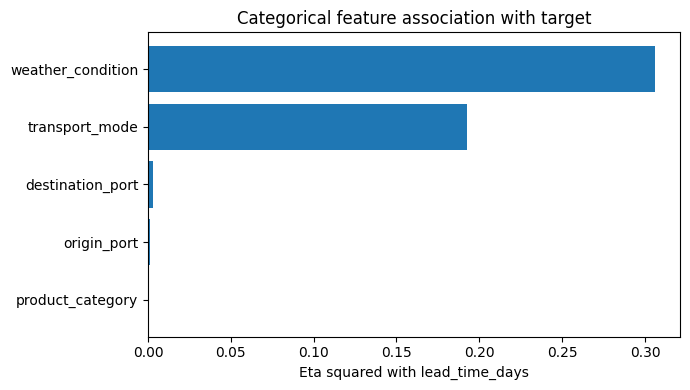

In [38]:
# Plot categorical feature association with target.
# Eta squared is used as an effect-size style measure for categorical feature vs numeric target.

plot_df = cat_target_assoc.sort_values("eta_squared")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(plot_df["feature"], plot_df["eta_squared"])
ax.set_xlabel("Eta squared with lead_time_days")
ax.set_title("Categorical feature association with target")
plt.tight_layout()
plt.show()

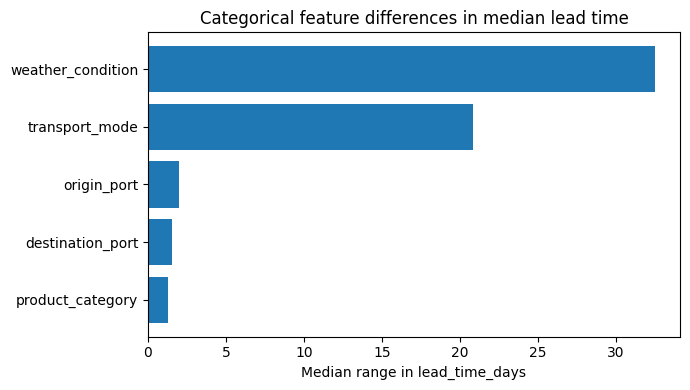

In [39]:
# Plot median lead-time range across category levels.
# This shows how much typical lead_time_days differs between the lowest- and highest-median category.

plot_df = cat_target_assoc.sort_values("median_range")

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(plot_df["feature"], plot_df["median_range"])
ax.set_xlabel("Median range in lead_time_days")
ax.set_title("Categorical feature differences in median lead time")
plt.tight_layout()
plt.show()

INTERPRETATION

most impactful numeric variables: distance_km and then geopolitical risk score  
most impactful categorical variables: weather_condition and then transport_mode  

## 6. Date and split feasibility

This section checks whether a time-based train/test split is feasible. A time-based split is preferred if the dataset covers enough months and enough rows in the later period.


In [20]:
date_summary = df_overlap["date"].agg(["min", "max"])
print(date_summary)

monthly_counts = (
    df_overlap
    .assign(month=df_overlap["date"].dt.to_period("M").astype(str))
    .groupby("month")
    .size()
    .rename("n_rows")
    .reset_index()
)

monthly_counts.tail(20)


min   2024-01-01
max   2024-12-31
Name: date, dtype: datetime64[ns]


,month,n_rows
0,2024-01,173
1,2024-02,195
2,2024-03,220
3,2024-04,229
4,2024-05,211
5,2024-06,208
6,2024-07,174
7,2024-08,199
8,2024-09,210
9,2024-10,215


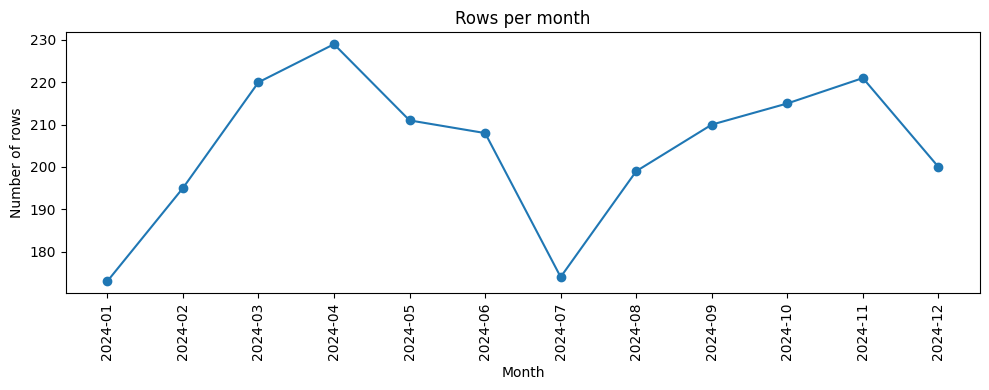

In [21]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(monthly_counts["month"], monthly_counts["n_rows"], marker="o")
ax.set_xlabel("Month")
ax.set_ylabel("Number of rows")
ax.set_title("Rows per month")
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()


In [40]:
split_date = pd.Timestamp("2024-10-01")

train_mask = df_overlap["date"] < split_date
test_mask = df_overlap["date"] >= split_date

train_df = df_overlap.loc[train_mask].copy()
test_df = df_overlap.loc[test_mask].copy()

print("Train rows:", len(train_df))
print("Test rows:", len(test_df))
print("Test share:", len(test_df) / len(df_overlap))
print("Train date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Test date range:", test_df["date"].min(), "to", test_df["date"].max())

Train rows: 1819
Test rows: 636
Test share: 0.2590631364562118
Train date range: 2024-01-01 00:00:00 to 2024-09-30 00:00:00
Test date range: 2024-10-01 00:00:00 to 2024-12-31 00:00:00


In [41]:
split_summary = pd.DataFrame({
    "train": train_df[TARGET_COL].describe(),
    "test": test_df[TARGET_COL].describe(),
})

split_summary

,train,test
count,1819.000000,636.000000
mean,19.101655,18.619167
std,30.568641,27.953538
min,0.500000,0.500000
25%,2.345000,1.907500
50%,8.290000,7.930000
75%,20.955000,22.087500
max,234.840000,222.480000


In [42]:
for col in categorical_feature_cols:
    train_levels = set(train_df[col].dropna().unique())
    test_levels = set(test_df[col].dropna().unique())

    print("\n" + "=" * 80)
    print(col)
    print("Train levels:", len(train_levels))
    print("Test levels:", len(test_levels))
    print("Only in test:", sorted(test_levels - train_levels))


origin_port
Train levels: 8
Test levels: 8
Only in test: []

destination_port
Train levels: 9
Test levels: 9
Only in test: []

transport_mode
Train levels: 4
Test levels: 4
Only in test: []

product_category
Train levels: 5
Test levels: 5
Only in test: []

weather_condition
Train levels: 5
Test levels: 5
Only in test: []


INTERPRETATION   

Split decision:
Use a chronological train/test split. Train on shipments from January to September 2024 and test on shipments from October to December 2024. The date column is used only for splitting and not as a model feature in version 1.

## 7. First modeling-feature decision draft

This cell creates a leakage-safe first feature set. Adjust this after inspecting the EDA outputs.


In [22]:
first_feature_set = {
    "numeric": [
        "distance_km",
        "weight_mt",
        "fuel_price_index",
        "geopolitical_risk_score",
        "carrier_reliability_score",
        "copper__usd_per_mt",
    ],
    "categorical": [
        "origin_port",
        "destination_port",
        "transport_mode",
        "product_category",
        "weather_condition",
    ],
    "excluded": EXCLUDE_FROM_FEATURES,
}

first_feature_set


{'numeric': ['distance_km',
  'weight_mt',
  'fuel_price_index',
  'geopolitical_risk_score',
  'carrier_reliability_score',
  'copper__usd_per_mt'],
 'categorical': ['origin_port',
  'destination_port',
  'transport_mode',
  'product_category',
  'weather_condition'],
 'excluded': ['shipment_id',
  'date',
  'month',
  'lead_time_days',
  'disruption_occurred']}

## EDA decisions for modeling

- Target: `lead_time_days`
- Target values are complete and positive.
- The target is right-skewed, but long-delay cases are plausible and retained.
- Numeric features are retained without outlier removal or transformation.
- Categorical features have low cardinality, no missing values, and sufficient category counts.
- Categorical features will be one-hot encoded inside the modeling pipeline.
- `shipment_id`, `date`, `month`, `lead_time_days`, and `disruption_occurred` are excluded from model inputs.
- `date` is used only for chronological splitting.
- Split: train on January–September 2024, test on October–December 2024.